# Experiment: Kuramoto 0321 Whitened Koopman Chain

本 notebook 用一个 Kuramoto 两团实验展示完整研究链条。目标是：把理论路径、公式、代码结构和结果输出放在同一个文件里，便于后续直接复用。

主链条如下：

1. 生成微观时间序列数据；
2. 固定时间滞后 $\tau$，构造配对样本 $(x_t, x_{t+\tau})$；
3. 选择观测函数并 lift，得到 $X_t = \chi_0(x_t)$ 和 $Y_t = \chi_1(x_{t+\tau})$；
4. 对观测变量中心化，得到 $\tilde X_t, \tilde Y_t$；
5. 计算
$$
C_{00} = \mathbb E[\tilde X_t \tilde X_t^\top], \qquad
C_{01} = \mathbb E[\tilde X_t \tilde Y_t^\top], \qquad
C_{11} = \mathbb E[\tilde Y_t \tilde Y_t^\top];
$$
6. 构造原始回归矩阵
$$
K_{\mathrm{raw}} = C_{00}^{\dagger} C_{01}
$$
以及双边白化矩阵
$$
\bar K = C_{00}^{-1/2} C_{01} C_{11}^{-1/2};
$$
7. 由 $\bar K$ 计算
$$
D_K = (I - \bar K^\top \bar K)^{-1}, \qquad
N_K = \bar K (I - \bar K^\top \bar K)^{-1} \bar K^\top;
$$
8. 计算主总分
$$
\mathcal G_\alpha^K = \left(\frac12 - \frac{\alpha}{4}\right) \log \operatorname{pdet}(N_K)
+ \frac{\alpha}{4} \log \operatorname{pdet}(D_K);
$$
9. 对 $K_{\mathrm{raw}}$ 和 $\bar K$ 做奇异值分解，其中 $K_{\mathrm{raw}}$ 只用于奇异值谱对比；
10. 只对 $\bar K$ 的奇异值谱计算 EC 序列和 EC 值；
11. 计算单通道得分 $g_i^K(\alpha)$ 与宏观效率增益
$$
\Delta g_\alpha^K(r)
= \frac1r \sum_{i=1}^r g_i^K(\alpha)
- \frac1{d_{\mathrm{eff}}} \sum_{i=1}^{d_{\mathrm{eff}}} g_i^K(\alpha);
$$
12. 用 $\bar K$ 的前 $r$ 个左奇异向量构造粗粒化函数和宏观变量。

这个 notebook 强调两点：

- $\bar K$ 是主研究对象，$K_{\mathrm{raw}}$ 只用于对照；
- 数据生成部分尽量独立，后面的分析块尽量复用。


## Block 1. 环境导入与统一风格

下面的代码块负责：

- 导入需要的库；
- 把仓库根目录加入 `sys.path`；
- 导入已有工具函数；
- 设置统一绘图风格；
- 定义少量 notebook 本地可视化辅助函数。

统一风格约定：

- 热力图默认使用 `vlag`；
- 同类图尽量保持同一种配色；
- 微观代表曲线只画少量变量，避免过密；
- 只在 notebook 中定义轻量辅助函数，不把实验专用绘图逻辑塞进 `tools.py`。


In [22]:
import sys
from pathlib import Path

REPO_ROOT = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / 'tools' / 'tools.py').exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root containing tools/tools.py')
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import pysindy as ps

from tools.tools import (
    compute_transition_covariances,
    fit_data_koopman_operator,
    whiten_operator_matrix,
    get_positive_contributions,
    compute_entropy,
    init_artifacts,
    analyze_kbar_metrics,
    build_macro_from_kbar,
    print_summary,
)
from data_generators.data_func import plot_clustered_kuramoto

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 160
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = [
    'Microsoft YaHei',
    'SimHei',
    'Noto Sans CJK SC',
    'Source Han Sans SC',
    'Arial Unicode MS',
    'DejaVu Sans',
]

HEATMAP_CMAP = 'vlag'


def sparse_labels(labels, step=1):
    if labels is None:
        return False
    if step <= 1:
        return labels
    return [label if idx % step == 0 else '' for idx, label in enumerate(labels)]


def plot_matrix_heatmap(matrix, title, row_labels=None, col_labels=None, center=0.0, figsize=(6, 5), label_step=1, cmap=HEATMAP_CMAP):
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        matrix,
        ax=ax,
        cmap=cmap,
        center=center,
        xticklabels=sparse_labels(col_labels, label_step),
        yticklabels=sparse_labels(row_labels, label_step),
    )
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)
    plt.tight_layout()
    plt.show()


def standardize_for_plot(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-12)


## Block 2. 全局参数配置

这里集中设置实验参数，不把关键超参数写死在后续单元里。

本实验的关键参数包括：

- Kuramoto 两团系统的数据参数；
- 数据整理参数，如 `burn_in_steps` 和 `sample_stride`；
- 主链条参数，如 `tau`、`lag_steps`、`alpha`、`eps`、`ridge`；
- 观测函数选择；
- 手动指定的截断维数 `rank`；
- 可视化时展示的代表性微观变量索引。

注意：这里的 `tau` 是“物理时间滞后”，而实际配对时的步长由 `lag_steps` 决定，因此一般有
$$
\tau = \text{lag\_steps} \times \Delta t_{\text{fit}}.
$$


In [23]:
config = {
    'experiment_name': 'exp_kuramoto_0321',
    'kuramoto': {
        'N': 10,
        'n_clusters': 2,
        'K_intra': 5.0,
        'K_inter': 0.11,
        'noise': 0.0,
        'T': 100.0,
        'dt': 0.01,
        'random_seed1': 0,
        'random_seed2': 0,
    },
    'burn_in_steps': 1000,
    'sample_stride': 1,  #15
    'lag_steps': 1, #60
    'rank': 2,
    'alpha': 1.0,
    'eps': 1e-10,
    'ridge': 1e-10,
    'observable_mode': 'identity + fourier', #手动
    'rank_candidates': [1, 2, 3, 4, 5, 6],
    'selected_micro_indices': [0, 5],
    'heatmap_label_step': 2,
    'top_k_features_to_show': 5,
}

artifacts = init_artifacts(config)
config


{'experiment_name': 'exp_kuramoto_0321',
 'kuramoto': {'N': 10,
  'n_clusters': 2,
  'K_intra': 5.0,
  'K_inter': 0.11,
  'noise': 0.0,
  'T': 100.0,
  'dt': 0.01,
  'random_seed1': 0,
  'random_seed2': 0},
 'burn_in_steps': 1000,
 'sample_stride': 1,
 'lag_steps': 1,
 'rank': 2,
 'alpha': 1.0,
 'eps': 1e-10,
 'ridge': 1e-10,
 'observable_mode': 'identity + fourier',
 'rank_candidates': [1, 2, 3, 4, 5, 6],
 'selected_micro_indices': [0, 5],
 'heatmap_label_step': 2,
 'top_k_features_to_show': 5}

## Block 3. 数据生成：Kuramoto 两团系统

下面的代码块调用现有的 Kuramoto 两团生成逻辑，参考已有 notebook 中 `plot_clustered_kuramoto` 的部分。

这里输出的是微观时间序列数据。对当前实验而言，原始状态使用的是 `sin/cos` 嵌入后的序列，因此原始数据已经是一个二维数组：
$$
X_{\mathrm{raw}} \in \mathbb R^{T \times d}.
$$

我们保留：

- 微观轨道 `x_data_raw`；
- 相位历史 `theta_hist`；
- 时间轴 `t_data_raw`；
- 耦合矩阵 `K_matrix_true`。

这一块是后续最方便替换的部分。以后做实验 2 时，理想情况下只换这里。


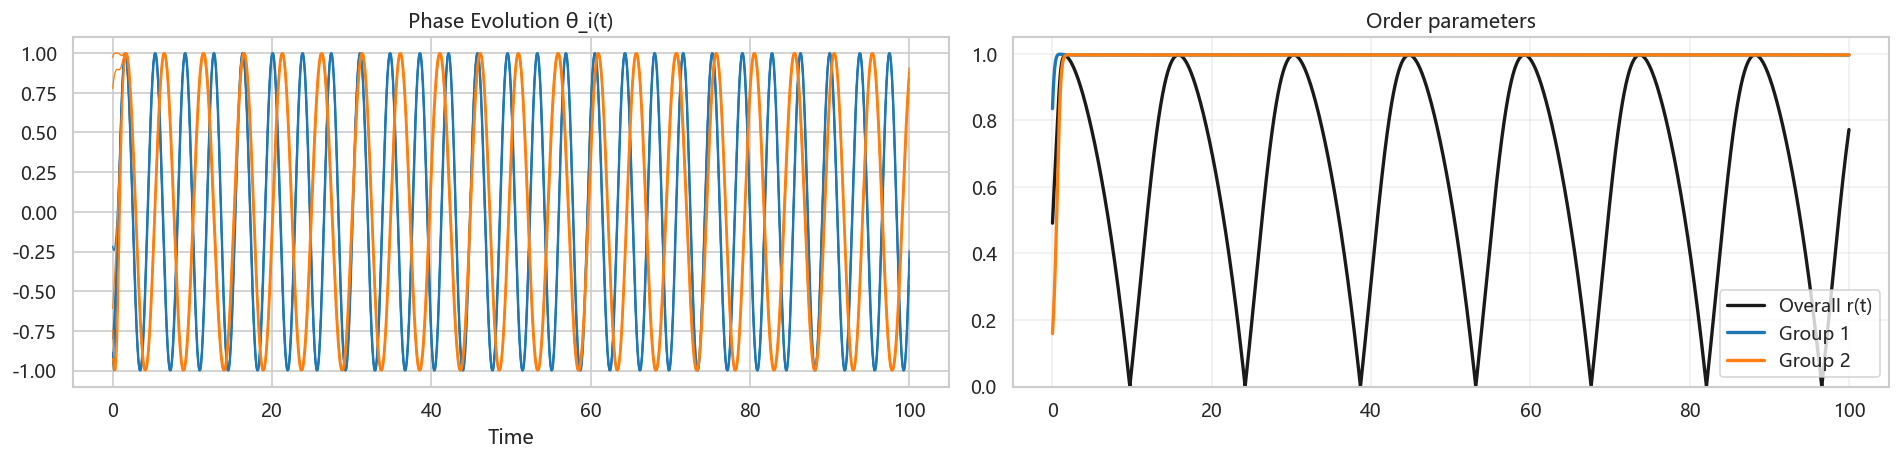

Raw data shape: (10000, 20)
Theta history shape: (10000, 10)
Time axis length: 10000
State dimension: 20
K matrix shape: (10, 10)


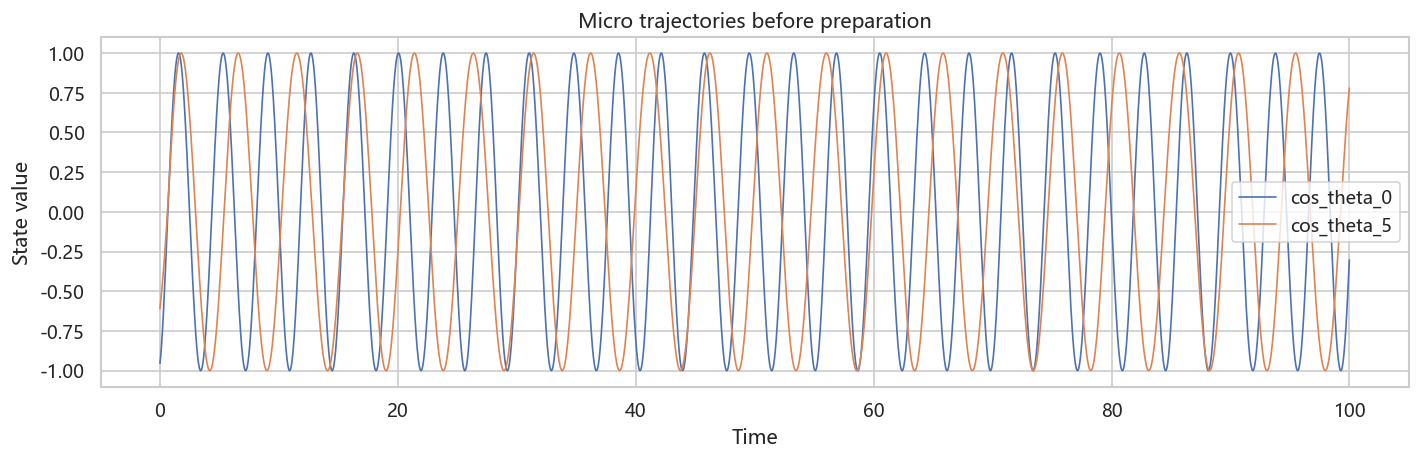

In [24]:
x_data_raw, theta_hist, t_data_raw, K_matrix_true = plot_clustered_kuramoto(**config['kuramoto'])

N = config['kuramoto']['N']
state_names_raw = [f'cos_theta_{i}' for i in range(N)] + [f'sin_theta_{i}' for i in range(N)]

artifacts['raw'] = {
    'x_data_raw': x_data_raw,
    'theta_hist': theta_hist,
    't_data_raw': t_data_raw,
    'K_matrix_true': K_matrix_true,
    'state_names_raw': state_names_raw,
}

print('Raw data shape:', x_data_raw.shape)
print('Theta history shape:', theta_hist.shape)
print('Time axis length:', len(t_data_raw))
print('State dimension:', x_data_raw.shape[1])
print('K matrix shape:', K_matrix_true.shape)

plt.figure(figsize=(12, 4))
for idx in config['selected_micro_indices']:
    plt.plot(t_data_raw, x_data_raw[:, idx], linewidth=1.0, label=state_names_raw[idx])
plt.title('Micro trajectories before preparation')
plt.xlabel('Time')
plt.ylabel('State value')
plt.legend()
plt.tight_layout()
plt.show()


## Block 4. 数据整理：不是强制标准化，而是统一输入格式

这个块的主要目的是 **data preparation**，不是强制标准化。

它负责：

- 去掉 burn-in；
- 进行可选下采样；
- 把数据整理成后续协方差估计和 Koopman 分析所需的统一格式；
- 输出 `x_data_fit`、`t_data_fit` 和 `state_names_fit`。

为什么需要这一步？

1. 不同实验的数据生成函数输出格式可能不同；
2. 主链条后面希望只依赖统一格式的数据；
3. 我们通常不希望把过渡阶段直接拿来估计 $C_{00}, C_{01}, C_{11}$；
4. 下采样可以减少冗余样本，让后面的可视化和矩阵计算更清晰。

因此，这一步更准确地说是“数据整理与统一”，而不是必须做 z-score 或 min-max 标准化。


Burn-in steps removed: 1000
Sample stride: 1
Prepared data shape: (9000, 20)
Prepared dt: 0.01
tau = lag_steps * dt_fit = 0.01


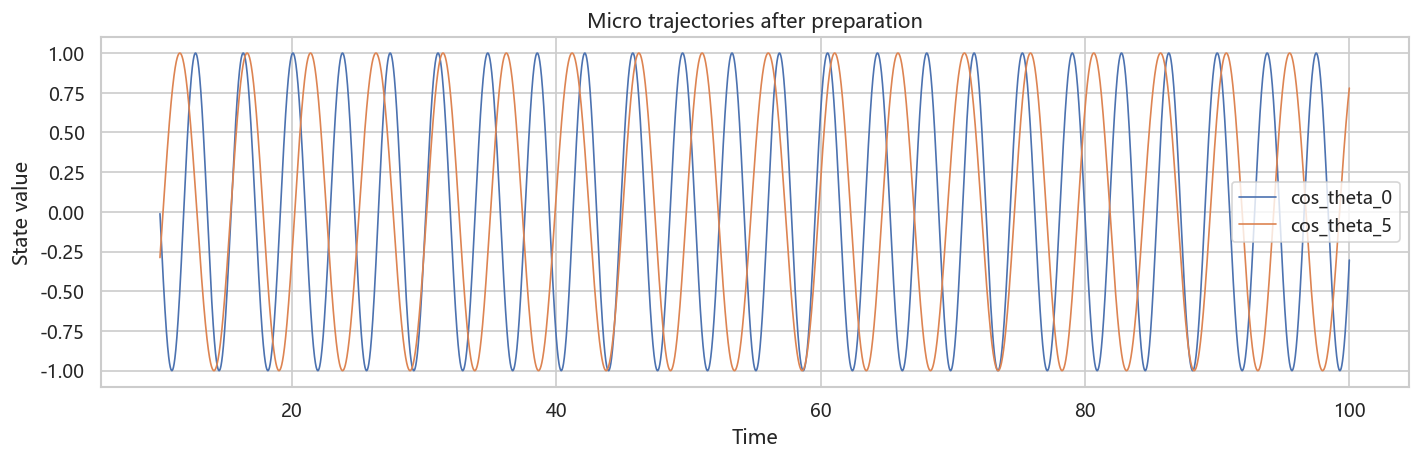

In [25]:
burn_in_steps = config['burn_in_steps']
sample_stride = config['sample_stride']

x_data_fit = x_data_raw[burn_in_steps::sample_stride].copy()
t_data_fit = t_data_raw[burn_in_steps::sample_stride].copy()
state_names_fit = state_names_raw.copy()
dt_fit = config['kuramoto']['dt'] * sample_stride
tau = config['lag_steps'] * dt_fit

artifacts['prep'] = {
    'x_data_fit': x_data_fit,
    't_data_fit': t_data_fit,
    'state_names_fit': state_names_fit,
    'dt_fit': dt_fit,
    'tau': tau,
}

print('Burn-in steps removed:', burn_in_steps)
print('Sample stride:', sample_stride)
print('Prepared data shape:', x_data_fit.shape)
print('Prepared dt:', dt_fit)
print('tau = lag_steps * dt_fit =', tau)

plt.figure(figsize=(12, 4))
for idx in config['selected_micro_indices']:
    plt.plot(t_data_fit, x_data_fit[:, idx], linewidth=1.0, label=state_names_fit[idx])
plt.title('Micro trajectories after preparation')
plt.xlabel('Time')
plt.ylabel('State value')
plt.legend()
plt.tight_layout()
plt.show()


## Block 5. 观测函数与 lift

现在选择观测函数 $\chi$，把原始微观数据映射到观测空间。

在本 notebook 中，这块先不封装成统一函数，直接在单元里写，保持实验特异性。候选的观测函数包括：

- `IdentityLibrary()`；
- `FourierLibrary()`；
- `PolynomialLibrary()`；
- `CustomLibrary()`。

本次实验的默认选择是
$$
\chi(x) = x,
$$
也就是 identity observable。后续换实验时，只要替换这一块，后面的主链条尽量可以继续复用。


In [26]:
ide = ps.IdentityLibrary()
fourier = ps.FourierLibrary(n_frequencies=1)
ode_lib = ps.PolynomialLibrary(degree=2, include_bias=False)
library_functions = [
    lambda x: 1,
    lambda x: x,
    lambda x: np.sin(x),
    lambda x: np.cos(x),
]
custom_library = ps.CustomLibrary(library_functions=library_functions)

library = ide + fourier
library.fit(x_data_fit)
x_data_lift = library.transform(x_data_fit)
raw_names = library.get_feature_names(input_features=state_names_fit)

x_data_lift_centered = x_data_lift - np.mean(x_data_lift, axis=0, keepdims=True)

artifacts['obs'] = {
    'library': library,
    'x_data_lift': x_data_lift,
    'x_data_lift_centered': x_data_lift_centered,
    'feature_names': raw_names,
    'observable_mode': config['observable_mode'],
}

x_data_lift = x_data_lift_centered # 不需要减去均值就注释掉，需要减去均值就正常保留

print('Observable mode:', config['observable_mode'])
print('Input shape:', x_data_fit.shape)
print('Lifted shape:', x_data_lift.shape)
print('First 10 feature names:', raw_names[:10])


Observable mode: identity + fourier
Input shape: (9000, 20)
Lifted shape: (9000, 60)
First 10 feature names: ['cos_theta_0', 'cos_theta_1', 'cos_theta_2', 'cos_theta_3', 'cos_theta_4', 'cos_theta_5', 'cos_theta_6', 'cos_theta_7', 'cos_theta_8', 'cos_theta_9']


## Block 6. 计算 $C_{00}$、$C_{01}$、$C_{11}$

这一块是研究链条的核心统计层。

我们根据中心化后的观测变量构造：

$$
C_{00} = \mathbb E[\tilde X_t \tilde X_t^\top],
\qquad
C_{01} = \mathbb E[\tilde X_t \tilde Y_t^\top],
\qquad
C_{11} = \mathbb E[\tilde Y_t \tilde Y_t^\top].
$$

其中当前与未来样本通过 `lag_steps` 对齐。这里统一调用已有工具函数 `compute_transition_covariances(...)`。


lag_steps = 1, tau = 0.010000
Pair count: 8999
C00 shape: (60, 60)
C01 shape: (60, 60)
C11 shape: (60, 60)
cond(C00): 3.2911854042259384e+18
cond(C11): 1.2333859414310062e+18
min eig(C00): -4.803470359909581e-16
min eig(C11): -4.361423613200542e-16


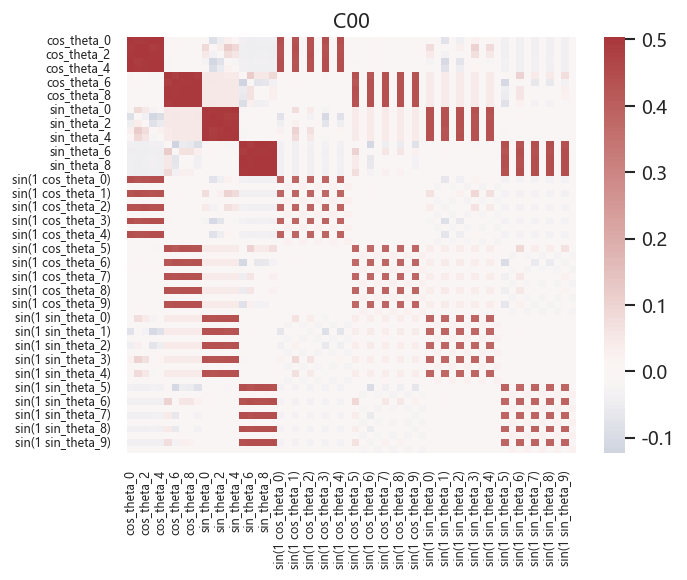

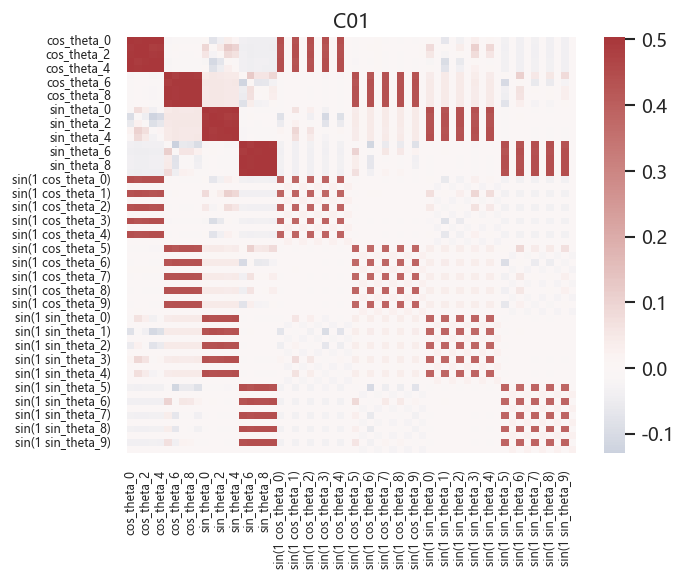

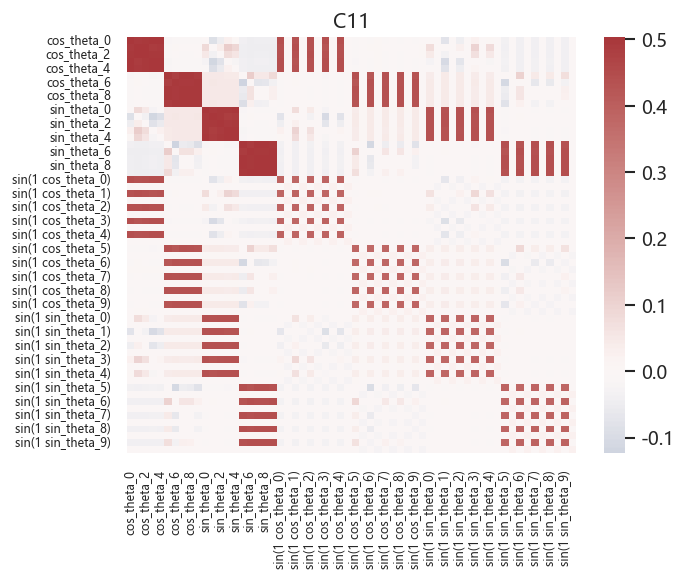

In [27]:
transition_stats = compute_transition_covariances(
    [x_data_lift],
    library=None,
    weights='uniform',
    lag_steps=config['lag_steps'],
)

C00 = transition_stats['C00']
C01 = transition_stats['C01']
C11 = transition_stats['C11']
X_pairs = transition_stats['X']
Y_pairs = transition_stats['Y']

artifacts['cov'] = {
    'transition_stats': transition_stats,
    'C00': C00,
    'C01': C01,
    'C11': C11,
    'X_pairs': X_pairs,
    'Y_pairs': Y_pairs,
}

print(f"lag_steps = {config['lag_steps']}, tau = {tau:.6f}")
print('Pair count:', X_pairs.shape[0])
print('C00 shape:', C00.shape)
print('C01 shape:', C01.shape)
print('C11 shape:', C11.shape)
print('cond(C00):', np.linalg.cond(C00))
print('cond(C11):', np.linalg.cond(C11))
print('min eig(C00):', np.min(np.linalg.eigvalsh(0.5 * (C00 + C00.T))))
print('min eig(C11):', np.min(np.linalg.eigvalsh(0.5 * (C11 + C11.T))))

plot_matrix_heatmap(C00, 'C00', row_labels=raw_names, col_labels=raw_names, label_step=config['heatmap_label_step'])
plot_matrix_heatmap(C01, 'C01', row_labels=raw_names, col_labels=raw_names, label_step=config['heatmap_label_step'])
plot_matrix_heatmap(C11, 'C11', row_labels=raw_names, col_labels=raw_names, label_step=config['heatmap_label_step'])


## Block 7. 构造 $K_{\mathrm{raw}}$ 与 $\bar K$

根据协方差矩阵，原始回归矩阵定义为
$$
K_{\mathrm{raw}} = C_{00}^{\dagger} C_{01},
$$
而双边白化矩阵定义为
$$
\bar K = C_{00}^{-1/2} C_{01} C_{11}^{-1/2}.
$$

在这里：

- `K_raw` 只用于后续奇异值谱对比；
- `K_bar` 才是主分析对象。

统一调用 `fit_data_koopman_operator(...)`，它会返回：

- 数据驱动的一步算子 `A`；
- 白化矩阵 `K_bar`；
- 白化所需的平方根与逆平方根矩阵。


K_raw shape: (60, 60)
K_bar shape: (60, 60)
||K_bar - K_bar_from_A||_F = 0.5323307337183097
sigma_max(K_bar) <= 1 ? approx = 1.0000000001337201


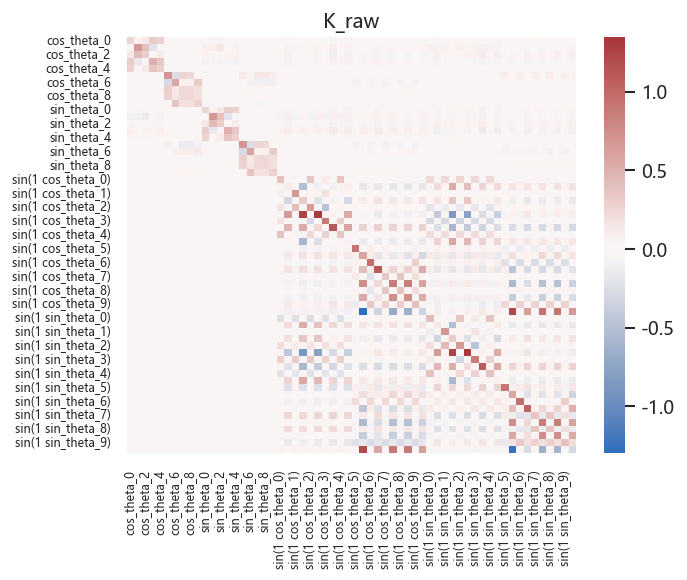

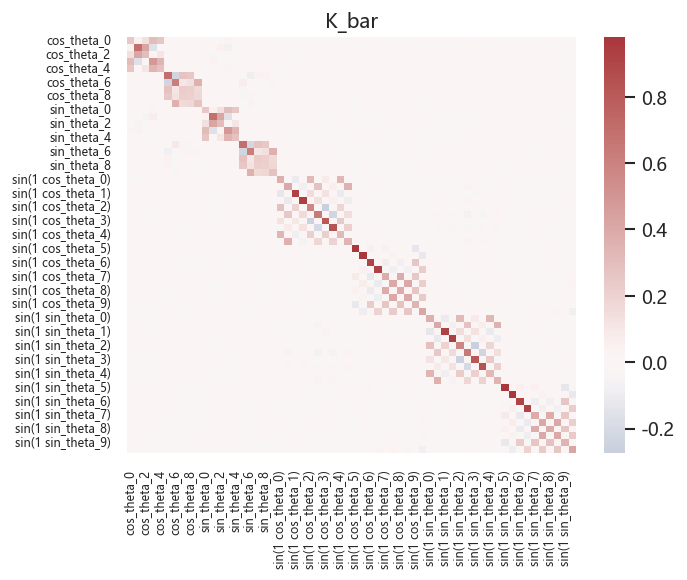

In [28]:
koop_fit = fit_data_koopman_operator(
    [x_data_lift],
    library=None,
    weights='uniform',
    eps=config['eps'],
    ridge=config['ridge'],
    lag_steps=config['lag_steps'],
)

K_raw = koop_fit['A']
K_bar = koop_fit['K_bar']
K_bar_from_A = koop_fit['K_bar_from_A']
C00_inv_sqrt = koop_fit['C00_inv_sqrt']
C11_inv_sqrt = koop_fit['C11_inv_sqrt']

artifacts['koopman'] = {
    'koop_fit': koop_fit,
    'K_raw': K_raw,
    'K_bar': K_bar,
    'K_bar_from_A': K_bar_from_A,
    'C00_inv_sqrt': C00_inv_sqrt,
    'C11_inv_sqrt': C11_inv_sqrt,
}

print('K_raw shape:', K_raw.shape)
print('K_bar shape:', K_bar.shape)
print('||K_bar - K_bar_from_A||_F =', np.linalg.norm(K_bar - K_bar_from_A))
print('sigma_max(K_bar) <= 1 ? approx =', np.linalg.svd(K_bar, compute_uv=False)[0])

plot_matrix_heatmap(K_raw, 'K_raw', row_labels=raw_names, col_labels=raw_names, label_step=config['heatmap_label_step'])
plot_matrix_heatmap(K_bar, 'K_bar', row_labels=raw_names, col_labels=raw_names, label_step=config['heatmap_label_step'])


## Block 8. 奇异值谱分析与 EC 指标

对白化矩阵做奇异值分解：

$$
\bar K = U \Sigma V^\top,
$$

同时对 `K_raw` 做奇异值分解，但 `K_raw` 只作为对照。

然后只对 $\bar K$ 的奇异值谱计算 EC 指标：

1. 用 `get_positive_contributions(S)` 得到 EC 序列；
2. 用 `compute_entropy(diff)` 得到一个 EC 数值。

这里的 EC 只基于 `K_bar` 的谱结构。


Top 10 singular values of K_bar: [1.         1.         1.         1.         1.         0.99999999
 0.99999997 0.99999997 0.99999997 0.99999992]
Top 10 singular values of K_raw: [5.61498071 4.46369694 1.72838411 1.60226282 1.56093609 1.5573766
 1.4502765  1.24391001 1.20737675 1.16184865]
EC entropy: 4.6629670272707155


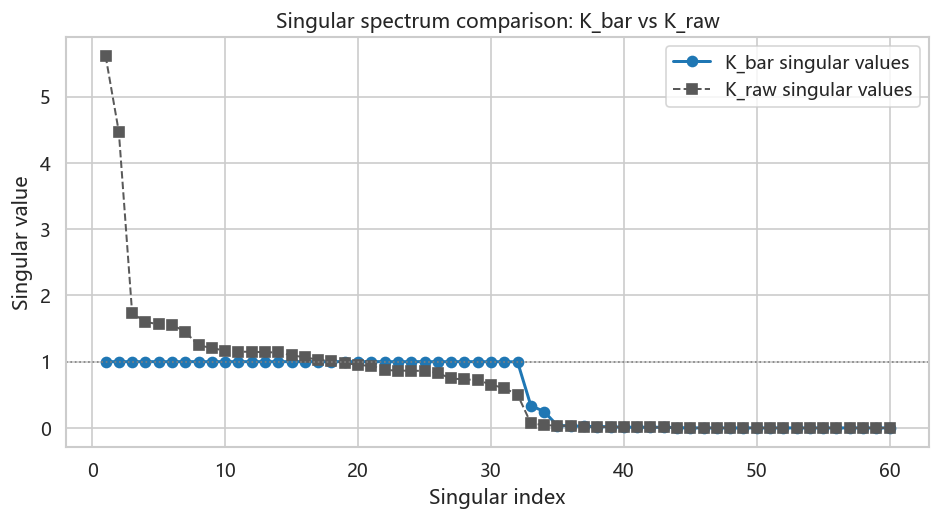

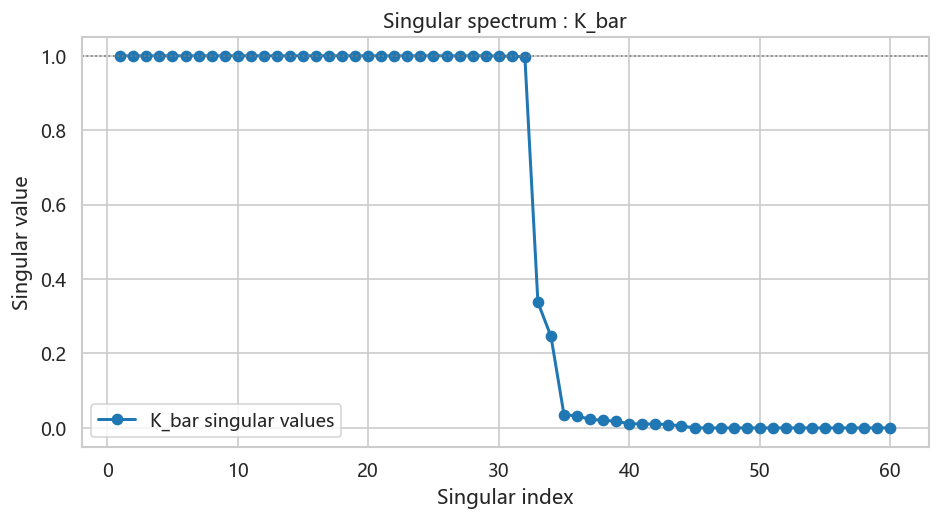

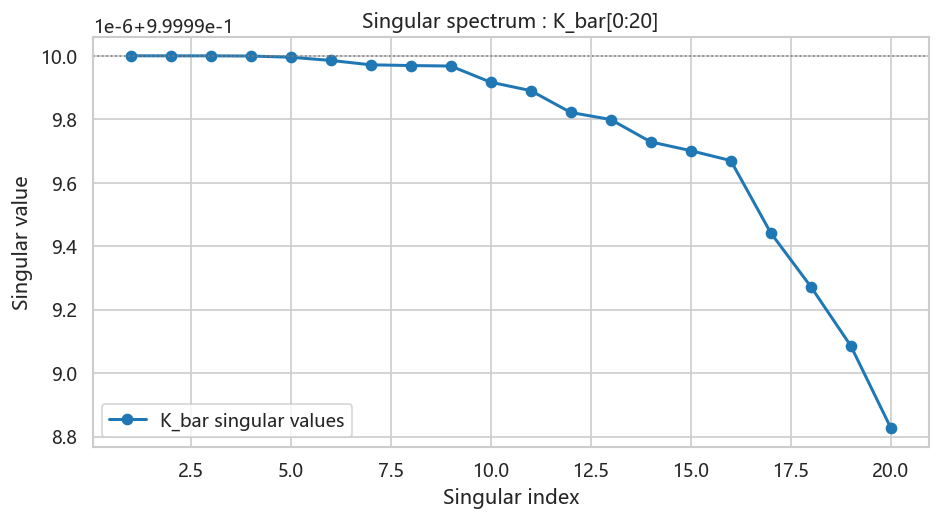

In [29]:
U_raw, S_raw, Vt_raw = np.linalg.svd(K_raw, full_matrices=False)
metrics = analyze_kbar_metrics(K_bar, alpha=config['alpha'], eps=config['eps'])

U_bar = metrics['U']
S_bar = metrics['S']
Vt_bar = metrics['Vt']

diff = get_positive_contributions(S_bar)
EC = compute_entropy(diff)

artifacts['spectral'] = {
    'U_raw': U_raw,
    'S_raw': S_raw,
    'Vt_raw': Vt_raw,
    'U_bar': U_bar,
    'S_bar': S_bar,
    'Vt_bar': Vt_bar,
    'diff': diff,
    'EC': EC,
}
artifacts['metrics']['kbar'] = metrics
artifacts['metrics']['EC'] = EC
artifacts['metrics']['EC_diff'] = diff

print('Top 10 singular values of K_bar:', S_bar[:10])
print('Top 10 singular values of K_raw:', S_raw[:10])
print('EC entropy:', EC)

fig, ax = plt.subplots(figsize=(8, 4.5))
idx_bar = np.arange(1, len(S_bar) + 1)
idx_raw = np.arange(1, len(S_raw) + 1)
ax.plot(idx_bar, S_bar, marker='o', linewidth=1.8, label='K_bar singular values', color='tab:blue')
ax.plot(idx_raw, S_raw, marker='s', linewidth=1.2, linestyle='--', label='K_raw singular values', color='0.35')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.0)
ax.set_xlabel('Singular index')
ax.set_ylabel('Singular value')
ax.set_title('Singular spectrum comparison: K_bar vs K_raw')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(idx_bar, S_bar, marker='o', linewidth=1.8, label='K_bar singular values', color='tab:blue')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.0)
ax.set_xlabel('Singular index')
ax.set_ylabel('Singular value')
ax.set_title('Singular spectrum : K_bar')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(idx_bar[0:20], S_bar[0:20], marker='o', linewidth=1.8, label='K_bar singular values', color='tab:blue')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.0)
ax.set_xlabel('Singular index')
ax.set_ylabel('Singular value')
ax.set_title('Singular spectrum : K_bar[0:20]')
ax.legend()
plt.tight_layout()
plt.show()


## Block 9. 计算 $D_K$、$N_K$ 与主总分 $\mathcal G_\alpha^K$

根据主链条，

$$
D_K = (I - \bar K^\top \bar K)^{-1},
\qquad
N_K = \bar K (I - \bar K^\top \bar K)^{-1} \bar K^\top.
$$

并定义主总分

$$
\mathcal G_\alpha^K = \left(\frac12 - \frac{\alpha}{4}\right) \log \operatorname{pdet}(N_K)
+ \frac{\alpha}{4} \log \operatorname{pdet}(D_K).
$$

这一块只围绕 $\bar K$ 展开，因为它才是主研究对象。边缘修正项在这个 notebook 中不作为主链条核心，只保留为以后可扩展的附加项。


log pdet(D_K): 366.7837533047524
log pdet(N_K): 141.10483314854898
G_alpha^K: 126.97214661332535


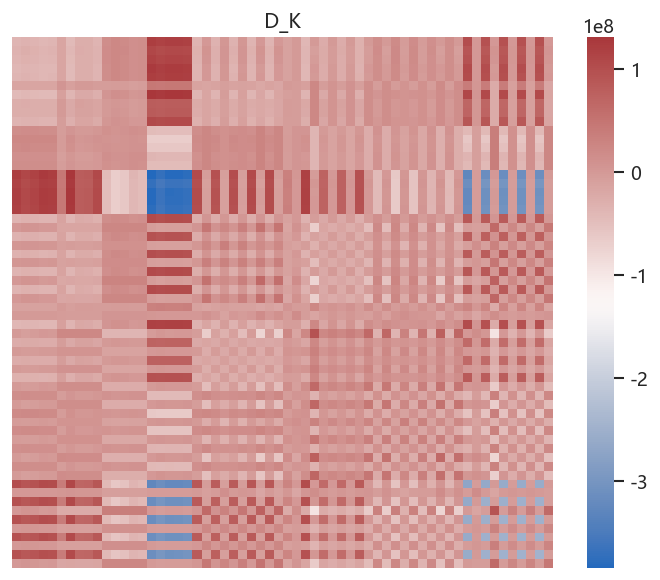

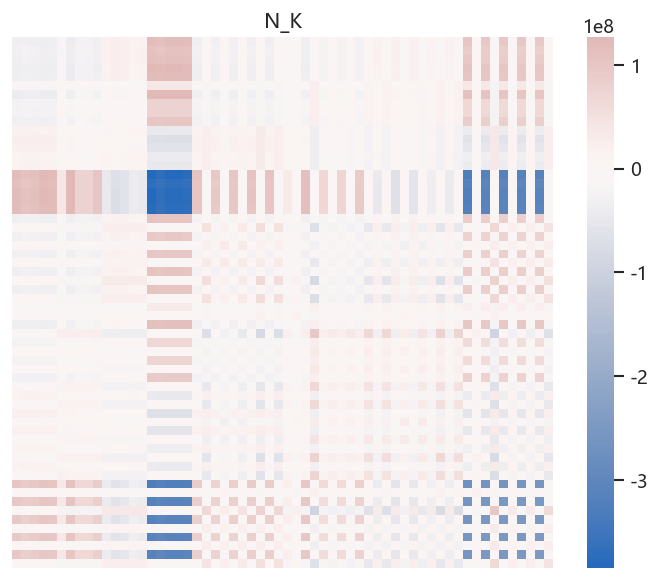

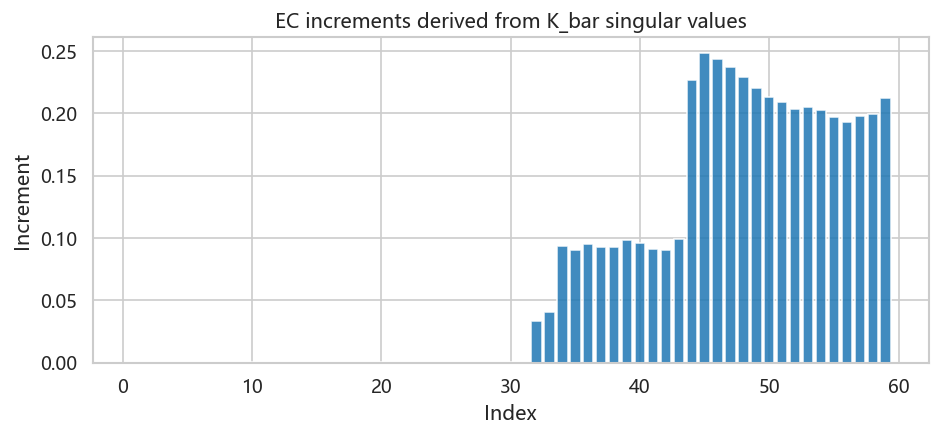

In [30]:
D_K = metrics['D_K']
N_K = metrics['N_K']
G_alpha_K = metrics['G_alpha_K']

print('log pdet(D_K):', metrics['log_pdet_D_K'])
print('log pdet(N_K):', metrics['log_pdet_N_K'])
print('G_alpha^K:', G_alpha_K)

plot_matrix_heatmap(D_K, 'D_K', center=None, figsize=(6, 5), cmap=HEATMAP_CMAP)
plot_matrix_heatmap(N_K, 'N_K', center=0.0, figsize=(6, 5), cmap=HEATMAP_CMAP)

plt.figure(figsize=(8, 3.8))
plt.bar(np.arange(1, len(diff) + 1), diff, color='tab:blue', alpha=0.85)
plt.title('EC increments derived from K_bar singular values')
plt.xlabel('Index')
plt.ylabel('Increment')
plt.tight_layout()
plt.show()


## Block 10. 截断维数 $r$、单通道得分与宏观效率增益

记 $\bar K$ 的奇异值为 $\rho_i = \sigma_i(\bar K)$，则单通道得分可以写成：

$$
g_i^K(\alpha)
= \left(\frac12 - \frac{\alpha}{4}\right) \log \frac{\rho_i^2}{1 - \rho_i^2}
+ \frac{\alpha}{4} \log \frac{1}{1 - \rho_i^2}.
$$

对于每个截断维数 $r$，定义宏观效率增益：

$$
\Delta g_\alpha^K(r)
= \frac1r \sum_{i=1}^r g_i^K(\alpha)
- \frac1{d_{\mathrm{eff}}} \sum_{i=1}^{d_{\mathrm{eff}}} g_i^K(\alpha).
$$

本实验暂时直接使用手动给定的 `rank = 2` 作为宏观维数，同时仍然计算不同 $r$ 下的 $\Delta g_\alpha^K(r)$ 作为参考。


Channel scores g_i^K(alpha): [11.51292542 11.51292542 11.51292542 10.32164083  9.27556915  8.68169697
  8.34432782  8.30523394  8.2803713   7.80510805  7.66626107  7.42285492
  7.36409328  7.21352531  7.16494365  7.11539988  6.85273309  6.72041024
  6.60618824  6.48150805  6.14300066  6.11035768  5.6724451   5.64156978
  4.94334131  4.90727561  4.69755974  4.69483532  3.85103593  3.5740892
  3.00744632  2.6714532  -0.48294097 -0.66963339 -1.673319   -1.71204467
 -1.89043688 -1.93811455 -2.02358396 -2.23939049 -2.27764374 -2.28523715
 -2.35043723 -2.63209547 -5.5995077  -5.75646273 -5.75646273 -5.75646273
 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273
 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273]
Delta g by r: {1: 9.713696661550632, 2: 9.713696661550632, 3: 9.713696661550635, 4: 9.415875514091862, 5: 9.02796848900406, 6: 8.670385109034463}
Selected r: 2


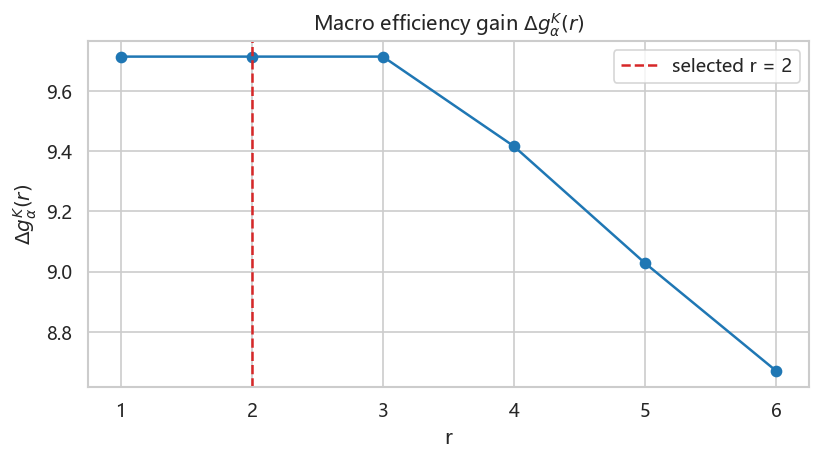

In [31]:
alpha = config['alpha']
eps = config['eps']
rho2 = np.clip(S_bar**2, eps, 1.0 - eps)
g_i = (0.5 - alpha / 4.0) * np.log(rho2 / (1.0 - rho2)) + (alpha / 4.0) * np.log(1.0 / (1.0 - rho2))

rank_candidates = [r for r in config['rank_candidates'] if 1 <= r <= len(g_i)]
delta_g_by_r = {
    r: float(np.mean(g_i[:r]) - np.mean(g_i))
    for r in rank_candidates
}
selected_r = int(config.get('rank', max(delta_g_by_r, key=delta_g_by_r.get)))

artifacts['metrics']['g_i'] = g_i
artifacts['metrics']['delta_g_by_r'] = delta_g_by_r
artifacts['metrics']['selected_r'] = selected_r

print('Channel scores g_i^K(alpha):', g_i)
print('Delta g by r:', delta_g_by_r)
print('Selected r:', selected_r)

plt.figure(figsize=(7, 4))
plt.plot(list(delta_g_by_r.keys()), list(delta_g_by_r.values()), marker='o', color='tab:blue')
plt.axvline(selected_r, color='tab:red', linestyle='--', label=f'selected r = {selected_r}')
plt.title(r'Macro efficiency gain $\Delta g_\alpha^K(r)$')
plt.xlabel('r')
plt.ylabel(r'$\Delta g_\alpha^K(r)$')
plt.legend()
plt.tight_layout()
plt.show()


## Block 11. 左奇异向量结构可视化

根据研究链条，当前侧粗粒化应选取 $\bar K$ 的左奇异子空间。因此，我们重点可视化：

- 全部左奇异向量矩阵 $U$；
- 左奇异向量绝对值矩阵 $|U|$；
- 前 $r$ 列左奇异向量；
- 前 $r$ 列左奇异向量绝对值。

这些图帮助我们判断：

- 哪些观测特征主导宏观通道；
- 前 $r$ 个通道是否呈现清晰的结构模式；
- 观测空间中是否存在明显的分群或块结构。


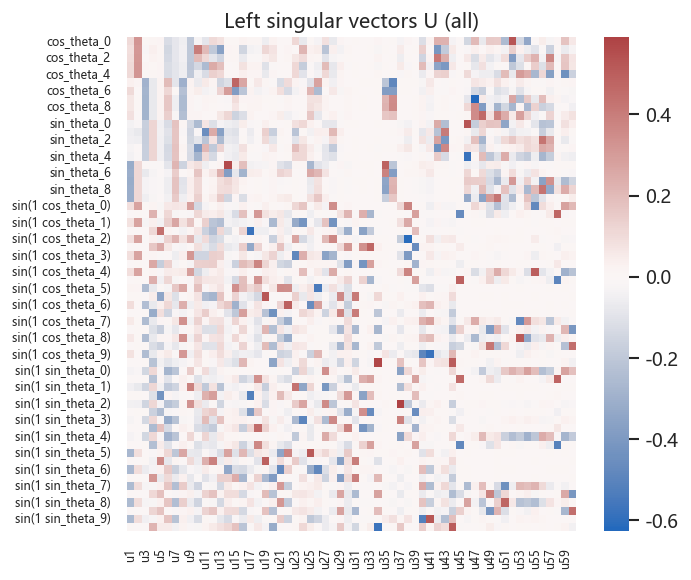

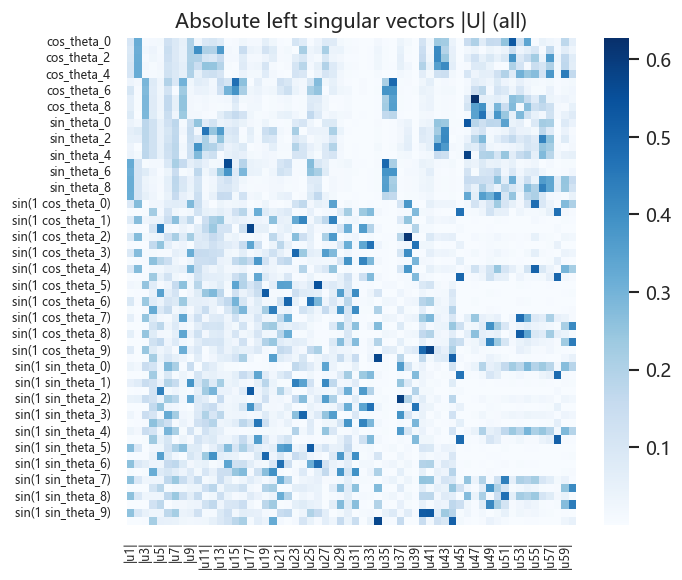

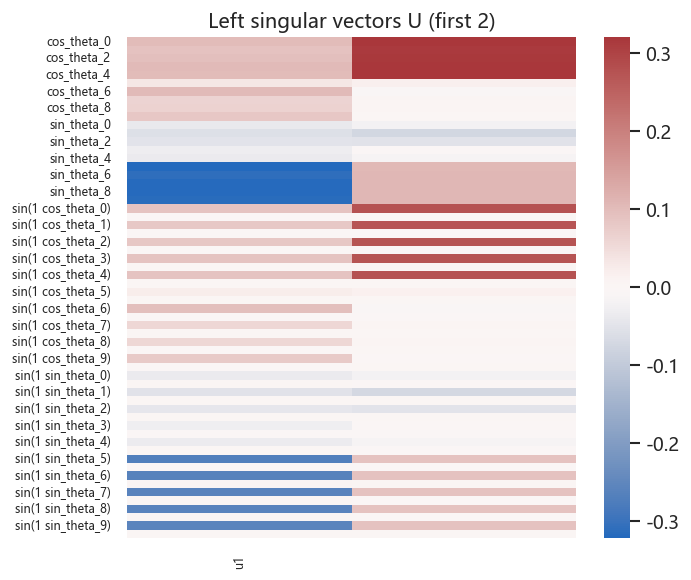

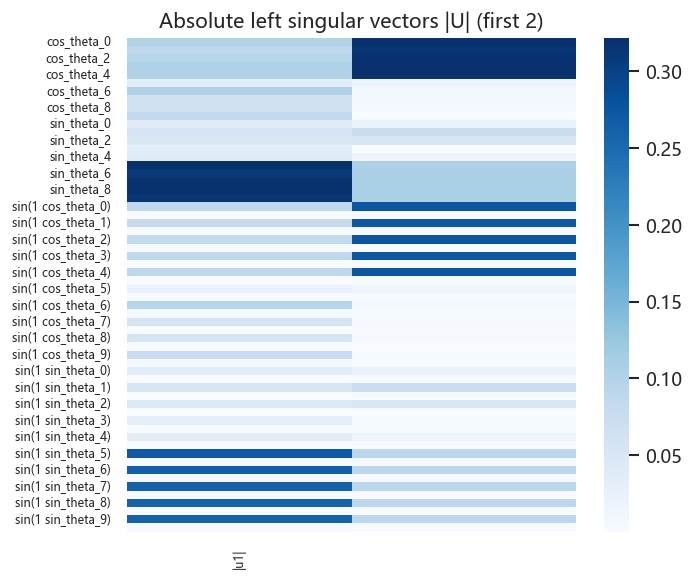

In [32]:
plot_matrix_heatmap(U_bar, 'Left singular vectors U (all)', row_labels=raw_names, col_labels=[f'u{i+1}' for i in range(U_bar.shape[1])], label_step=config['heatmap_label_step'])
plot_matrix_heatmap(np.abs(U_bar), 'Absolute left singular vectors |U| (all)', row_labels=raw_names, col_labels=[f'|u{i+1}|' for i in range(U_bar.shape[1])], center=None, label_step=config['heatmap_label_step'], cmap='Blues')
plot_matrix_heatmap(U_bar[:, :selected_r], f'Left singular vectors U (first {selected_r})', row_labels=raw_names, col_labels=[f'u{i+1}' for i in range(selected_r)], label_step=config['heatmap_label_step'])
plot_matrix_heatmap(np.abs(U_bar[:, :selected_r]), f'Absolute left singular vectors |U| (first {selected_r})', row_labels=raw_names, col_labels=[f'|u{i+1}|' for i in range(selected_r)], center=None, label_step=config['heatmap_label_step'], cmap='Blues')


## Block 12. 构造粗粒化函数与宏观变量

根据前 $r$ 个左奇异向量，构造当前侧宏观变量：

$$
z_t = U_r^\top C_{00}^{-1/2} \tilde X_t.
$$

在行向量约定下，这等价于把每个样本先做白化，再投影到前 $r$ 个左奇异方向上。

这里统一调用新增函数 `build_macro_from_kbar(...)`，它会返回：

- `U_r`；
- 当前侧宏观变量 `z_current`；
- 可选未来侧宏观变量 `z_future`；
- 粗粒化系数矩阵；
- 每个宏观变量对应的主导特征列表。


In [33]:
macro = build_macro_from_kbar(
    U=U_bar,
    S=S_bar,
    Vt=Vt_bar,
    C00_inv_sqrt=C00_inv_sqrt,
    X=X_pairs,
    r=selected_r,
    feature_names=raw_names,
    Y=Y_pairs,
    C11_inv_sqrt=C11_inv_sqrt,
    center=False,
)

artifacts['macro'] = macro

print('Macro current shape:', macro['z_current'].shape)
print('Macro future shape:', None if macro['z_future'] is None else macro['z_future'].shape)
print('Top features per macro component:')
for idx, items in enumerate(macro['dominant_features'], start=1):
    print(f'  Component {idx}:')
    display(pd.DataFrame(items))


Macro current shape: (8999, 2)
Macro future shape: (8999, 2)
Top features per macro component:
  Component 1:


,feature,weight,abs_weight
0,sin(1 sin_theta_6),-68.657412,68.657412
1,sin(1 sin_theta_5),-64.256754,64.256754
2,sin(1 sin_theta_8),50.284992,50.284992
3,sin(1 sin_theta_7),49.041502,49.041502
4,sin(1 sin_theta_9),26.530839,26.530839


  Component 2:


,feature,weight,abs_weight
0,sin(1 cos_theta_3),-15.960729,15.960729
1,sin(1 cos_theta_2),13.280849,13.280849
2,sin(1 cos_theta_1),-10.094653,10.094653
3,sin(1 cos_theta_6),7.991731,7.991731
4,sin(1 cos_theta_0),7.714115,7.714115


## Block 13. 宏观数据与宏微观对比

这一块用来展示：

- 宏观时间序列；
- 微观代表变量的时间序列；
- 宏微观对比图；
- 宏观热力图。

为了便于对比，不同量纲的曲线在同一张图中会做 **仅用于展示的标准化**：

$$
\hat x = \frac{x - \mu_x}{\sigma_x + 10^{-12}}.
$$

这一步只是为了画图，不影响前面的协方差估计和主链条计算。


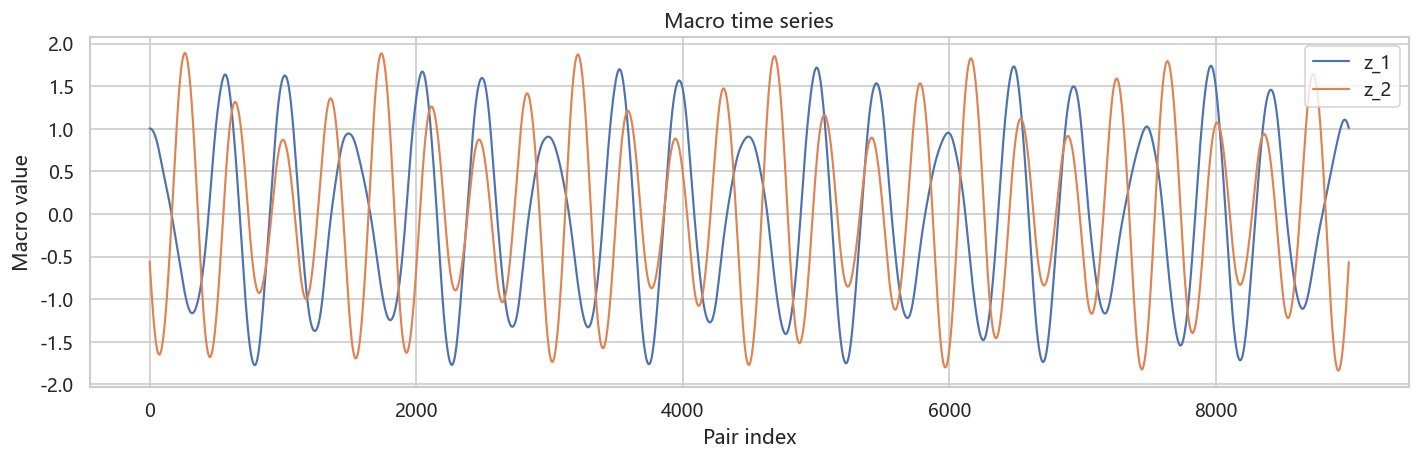

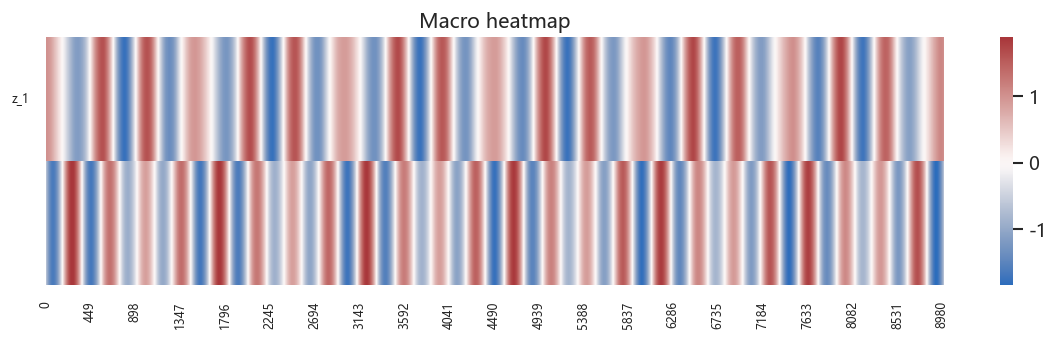

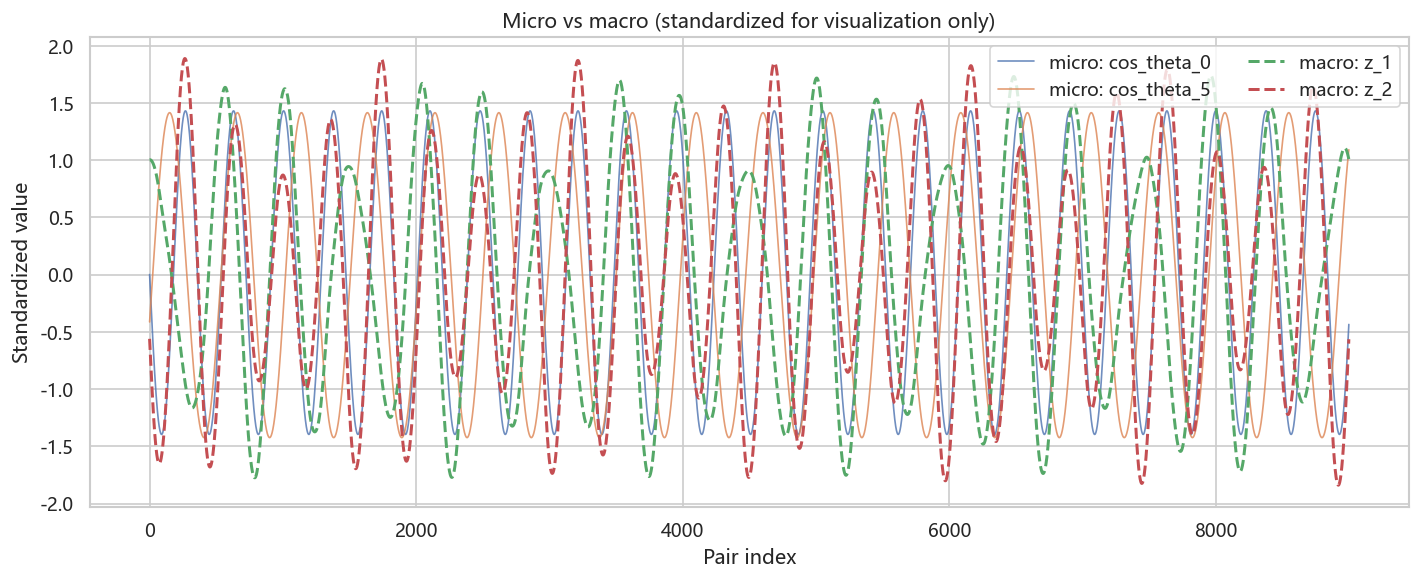

In [34]:
z_current = macro['z_current']
macro_names = [f'z_{i+1}' for i in range(selected_r)]

plt.figure(figsize=(12, 4))
for i in range(selected_r):
    plt.plot(z_current[:, i], linewidth=1.3, label=macro_names[i])
plt.title('Macro time series')
plt.xlabel('Pair index')
plt.ylabel('Macro value')
plt.legend()
plt.tight_layout()
plt.show()

plot_matrix_heatmap(z_current.T, 'Macro heatmap', row_labels=macro_names, col_labels=[str(i) for i in range(z_current.shape[0])], center=0.0, figsize=(10, 3), label_step=max(1, z_current.shape[0] // 20))

plt.figure(figsize=(12, 5))
for idx in config['selected_micro_indices']:
    plt.plot(standardize_for_plot(X_pairs[:, idx]), linewidth=1.0, alpha=0.8, label=f'micro: {raw_names[idx]}')
for i in range(selected_r):
    plt.plot(standardize_for_plot(z_current[:, i]), linewidth=1.8, linestyle='--', label=f'macro: {macro_names[i]}')
plt.title('Micro vs macro (standardized for visualization only)')
plt.xlabel('Pair index')
plt.ylabel('Standardized value')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


## Block 14. 统一摘要输出

最后把关键结果统一整理输出，便于快速检查当前实验结果是否完整。

这里重点输出：

- 数据大小、滞后和维数；
- 协方差矩阵大小；
- `K_raw` 和 `K_bar` 的大小；
- $\sigma_{\max}(\bar K)$；
- 主总分 $\mathcal G_\alpha^K$；
- EC 值；
- 选中的截断维数 $r$；
- 前 $r$ 个奇异值；
- $\Delta g_\alpha^K(r)$。


In [35]:
summary_dict = {
    'experiment': {
        'name': config['experiment_name'],
        'observable_mode': config['observable_mode'],
        'alpha': config['alpha'],
        'eps': config['eps'],
        'ridge': config['ridge'],
    },
    'data': {
        'raw_shape': x_data_raw.shape,
        'prepared_shape': x_data_fit.shape,
        'lifted_shape': x_data_lift.shape,
        'pair_count': X_pairs.shape[0],
        'dt_fit': dt_fit,
        'tau': tau,
        'lag_steps': config['lag_steps'],
    },
    'covariances': {
        'C00_shape': C00.shape,
        'C01_shape': C01.shape,
        'C11_shape': C11.shape,
        'cond_C00': float(np.linalg.cond(C00)),
        'cond_C11': float(np.linalg.cond(C11)),
    },
    'koopman': {
        'K_raw_shape': K_raw.shape,
        'K_bar_shape': K_bar.shape,
        'sigma_max_K_bar': metrics['sigma_max'],
        'effective_rank': metrics['effective_rank'],
    },
    'scores': {
        'G_alpha_K': metrics['G_alpha_K'],
        'EC': EC,
        'selected_r': selected_r,
        'top_r_singular_values': S_bar[:selected_r],
        'delta_g_selected_r': delta_g_by_r[selected_r],
    },
}

artifacts['summary'] = summary_dict
print_summary(summary_dict)


Summary

[experiment]
           item              value
           name  exp_kuramoto_0321
observable_mode identity + fourier
          alpha                1.0
            eps                0.0
          ridge                0.0

[data]
          item       value
     raw_shape (10000, 20)
prepared_shape  (9000, 20)
  lifted_shape  (9000, 60)
    pair_count        8999
        dt_fit        0.01
           tau        0.01
     lag_steps           1

[covariances]
     item                  value
C00_shape               (60, 60)
C01_shape               (60, 60)
C11_shape               (60, 60)
 cond_C00  3291185404225938432.0
 cond_C11  1233385941431006208.0

[koopman]
           item    value
    K_raw_shape (60, 60)
    K_bar_shape (60, 60)
sigma_max_K_bar      1.0
 effective_rank       60

[scores]
                 item       value
            G_alpha_K  126.972147
                   EC    4.662967
           selected_r           2
top_r_singular_values    [1., 1.]
   delta_g_sele